In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [3]:
SAMPLING_RATE = 16_000 # podemos ir cambiando este valor
PREEMPH = None # puede ser 0.97 o 0.95 también

In [10]:
def plot_mel(y, sr=SAMPLING_RATE, ax=None, title="Mel-spectrograma", show_colorbar=False):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))

    # Mel-spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    S_db_mel = librosa.power_to_db(S, ref=np.max)

    img = librosa.display.specshow(S_db_mel, sr=sr, x_axis='time', y_axis='mel',
                                   fmax=8000, cmap='magma', ax=ax)
    ax.set_title(title)

    if show_colorbar:
        plt.colorbar(img, ax=ax, format='%+2.0f dB')

    return img

# Enhacement

Tenemos que verificar que es posible mejorar los audios grabados con micrófonos convencionales al nivel que el modelo esperará.

## Resampling

Los celulares suelen tener un sampling rate de 16 kHz o 22.05 kHz

Pre-emphasis es un filtro que puede llegar a servir.

In [11]:
def load_resample(path, sr_target=SAMPLING_RATE, preemph=PREEMPH):
    y, sr = librosa.load(path, sr=None)
    # resampleamos si es necesario
    if sr != sr_target:
        y = librosa.resample(y, orig_sr=sr, target_sr=sr_target)
        sr = sr_target
    # pre-emphasis
    if preemph is not None:
        y = np.append(y[0], y[1:] - preemph * y[:-1])
    return y, sr

In [12]:
path = './audios_propios/ciclo1.ogg'
y, sr = load_resample(path)
y2, sr2 = load_resample(path, sr_target=22_050)  # sin preemphasis y con otro sr
y3, sr3 = load_resample(path, preemph=0.97)
y4, sr4 = load_resample(path, sr_target=22_050, preemph=0.97)

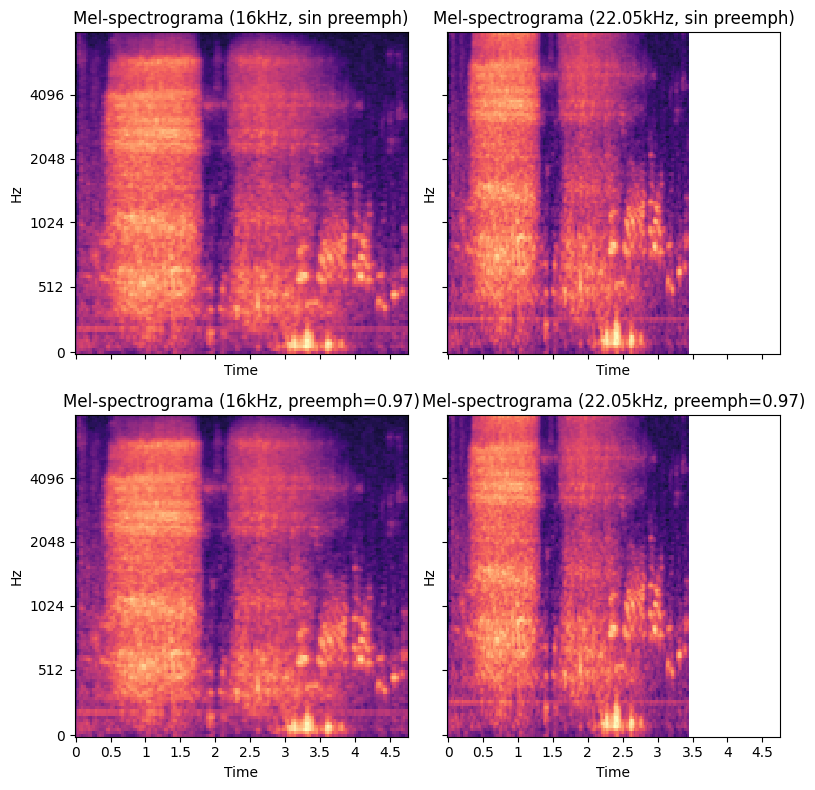

In [13]:
_, axs = plt.subplots(2, 2, figsize=(8, 8), sharex=True, sharey=True)
plot_mel(y, sr=sr, ax=axs[0, 0], title="Mel-spectrograma (16kHz, sin preemph)")
plot_mel(y, sr=sr2, ax=axs[0, 1], title="Mel-spectrograma (22.05kHz, sin preemph)")
plot_mel(y, sr=sr3, ax=axs[1, 0], title="Mel-spectrograma (16kHz, preemph=0.97)")
plot_mel(y, sr=sr4, ax=axs[1, 1], title="Mel-spectrograma (22.05kHz, preemph=0.97)")
plt.tight_layout()
plt.show()

Los sonidos respiratorios no suelen pasar los 4 Khz entonces, por el teorema de Nysquit, cualquier sampling rate mayor a 8 Khz nos sirve.  
Usando 16 kHz capturamos cómodamente todo el espectro relevante y más, si aumentamos mucho más aumentaríamos también el tamaño de los archivos y la carga computacional innecesariamente.

En el gráfico anterior se ve como aumentar el sampling rate agrega ruido (ver arriba a la derecha)

## Reducción de Ruido

Hay varios métodos para probar:
+ Sustracción Espectral
+ Filtro Adaptativo LMS
+ Wiener Filter
+ Simple spectral gating
+ Denoising Autoencoder (REVISAR)

### Sustracción espectral

In [20]:
def spectral_subtract(y, sr, n_fft=1024, hop_length=512, win_length=1024, alpha=1.5):
    S = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, win_length=win_length)
    mag, phase = np.abs(S), np.angle(S)
    # estimate noise as median of lowest-energy frames OR first 0.5s
    # aquí simplificamos: usar median across time
    noise_mag = np.median(mag, axis=1, keepdims=True)
    # subtraction
    mag_denoised = mag - alpha * noise_mag
    mag_denoised = np.maximum(mag_denoised, 1e-10)
    S_d = mag_denoised * np.exp(1j * phase)
    y_d = librosa.istft(S_d, hop_length=hop_length, win_length=win_length)
    return y_d, sr

Probar con distintos $\alpha$

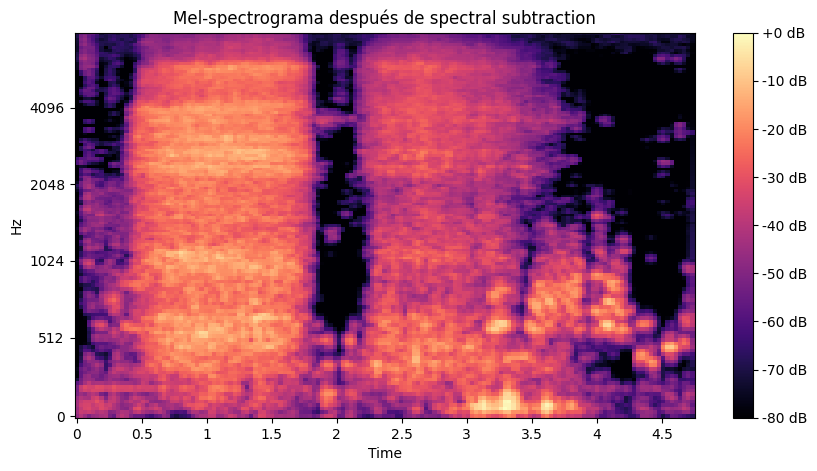

In [33]:
y_d, sr = spectral_subtract(y, sr, alpha=0.5)

plot_mel(y_d, sr=sr, title="Mel-spectrograma después de spectral subtraction", show_colorbar=True);

## Filtrado Low-pass / Band-pass

Respiración y sibilancias suelen < ~4–6 kHz; probamos:
+ Low-pass a 4 kHz, 6 kHz, 8 kHz.
+ Band-pass 100 Hz – 4000 Hz (elimina DC y ruido muy bajo).

Filtros: FIR (ventana) o IIR (Butterworth) — FIR (lineal fase) evita distorsión de fase si importante.

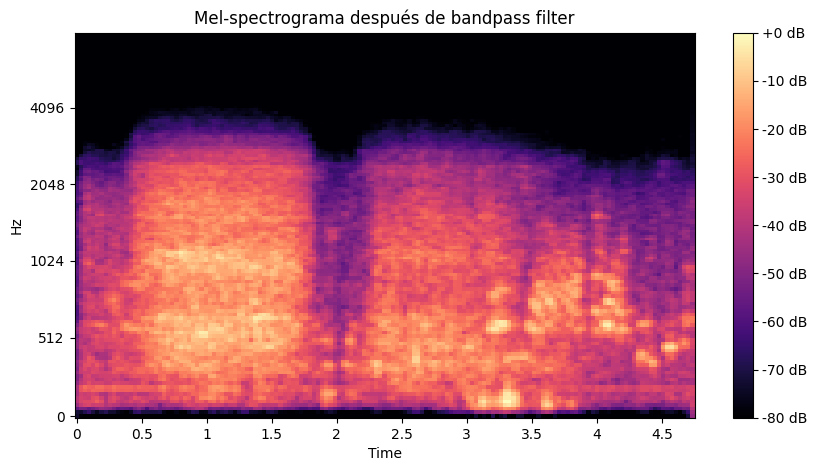

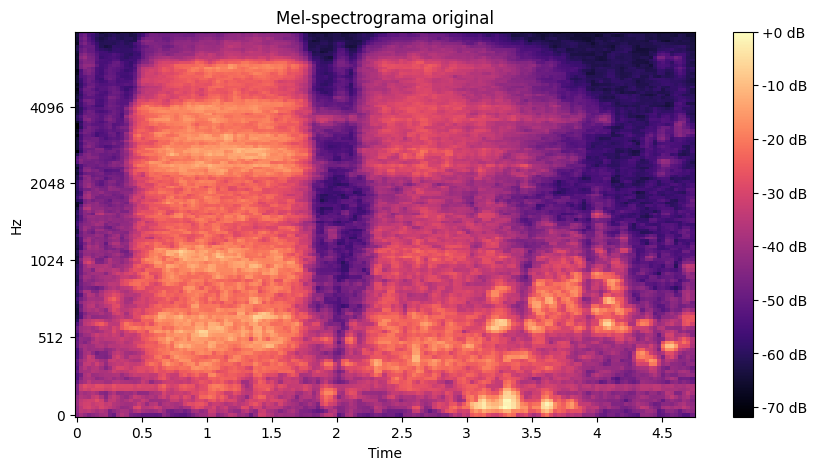

In [36]:
# Definir los cortes del filtro (Hz)
lowcut = 100.0
highcut = 2000.0

# Normalizar (frecuencia/ Nyquist)
nyquist = 0.5 * sr
low = lowcut / nyquist
high = highcut / nyquist

# Diseñar filtro Butterworth (orden 4 está bien como inicio)
b, a = scipy.signal.butter(4, [low, high], btype='band')

# Aplicar el filtro
y_filt = scipy.signal.filtfilt(b, a, y)

# Comparar antes y después
plot_mel(y_filt, sr=sr, title="Mel-spectrograma después de bandpass filter", show_colorbar=True);
plot_mel(y, sr=sr, title="Mel-spectrograma original", show_colorbar=True);

Eso es un bandpass filter. Me parece que puede ser mejor un low pass ya que claramente perdimos información.

## Normalización ???

# Domain Shift

# Comparación